[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Generalization:  the Goal of Machine Learning

Consider two college students diligently
preparing for their final exam.
Commonly, this preparation will consist
of practicing and testing their abilities
by taking exams administered in previous years.
Nonetheless, doing well on past exams is no guarantee
that they will excel when it matters.
For instance, imagine a student, Extraordinary Ellie,
whose preparation consisted entirely
of memorizing the answers
to previous years' exam questions.
Even if Ellie were endowed
with an extraordinary memory,
and thus could perfectly recall the answer
to any **previously seen** question,
she might nevertheless freeze
when faced with a new, **unseen** question.
By comparison, imagine another student,
Inductive Irene, with comparably poor
memorization skills,
but a knack for picking up patterns.
Note that if the exam truly consisted of
recycled questions from a previous year,
Ellie would handily outperform Irene.
Even if Irene's inferred patterns
yielded 90% accurate predictions,
they could never compete with
Ellie's 100% recall.
However, even if the exam consisted
entirely of fresh questions,
Irene might maintain her 90% average.

As machine learning scientists,
**our goal is to discover patterns**.
**But how can we be sure that we have
truly discovered general patterns
and not simply memorized our data?**
Most of the time, our predictions are only useful
if our model discovers such patterns.
We do not want to predict yesterday's stock prices, but tomorrow's.
We do not need to recognize
already diagnosed diseases
for previously seen patients,
but rather previously undiagnosed
ailments in previously unseen patients.
This problem---how to discover patterns that *generalize*---is
the fundamental problem of machine learning,
and arguably of all of statistics.
We might cast this problem as just one slice
of a far grander question
that engulfs all of science:
when are we ever justified
in making the leap from particular observations
to more general statements?


In real life, we must fit our models using a finite collection of data.
The typical scales of that data vary wildly across domains.
For many important medical problems, we can only access a few thousand data points.
When studying rare diseases, we might be lucky to access hundreds.
By contrast, the largest public datasets consisting of labeled photographs,
e.g., ImageNet, contain millions of images.
And some unlabeled image collections such as the Flickr YFC100M dataset
can be even larger, containing over 100 million images.
However, even at this extreme scale, the number of available data points
remains infinitesimally small compared to the space of all possible images at a megapixel resolution.
Whenever we work with finite samples,
we must keep in mind the risk that we might fit our training data,
only to discover that we failed to discover generalizable patterns.

The phenomenon of fitting closer to the training data than to the underlying distribution is called **overfitting**, and techniques for combatting overfitting are called **regularization** methods.
We will revisit generalization  throughout the course, exploring both what is known about the principles underlying generalization in various models, and also techniques that have been found (empirically) to yield improved generalization on tasks of practical interest.


## Training Error vs Generalization Error

In the standard supervised learning setting, we assume that the training data and the test data are drawn *independently* from *identical* distributions.
This is commonly called the *IID assumption*.
This is the assumption that the training data reflects the expected characteristics that you expect when deploying the model.

To begin with, we need to differentiate between
the *training error* $R_\textrm{emp}$,
which is a *statistic*
calculated on the training dataset,
and the *generalization error* $R$,
which is an *expectation* taken
with respect to the underlying distribution.
You can think of the generalization error as
what you would see  if you applied your model
to an infinite stream of additional data examples
drawn from the same underlying data distribution.
Formally the training error is expressed as

$$R_\textrm{emp}[\mathbf{X}, \mathbf{y}, f] = \frac{1}{n} \sum_{i=1}^n l(\mathbf{x}^{(i)}, y^{(i)}, f(\mathbf{x}^{(i)})),$$


while the generalization error is expressed as:

$$R[p, f] = E_{(\mathbf{x}, y) \sim P} [l(\mathbf{x}, y, f(\mathbf{x}))] =
\int \int l(\mathbf{x}, y, f(\mathbf{x})) p(\mathbf{x}, y) \;d\mathbf{x} dy.$$

Problematically, we can never calculate
the generalization error $R$ exactly.
We don't have access to the density function $p(\mathbf{x}, y)$, and we cannot
sample an infinite stream of data points from that distribution.
Thus, in practice, we must **estimate the generalization error by applying our model to an independent test set** consisting of a random selection of examples $\mathbf{X}'$ and their labels $\mathbf{y}'$ that were withheld from our training set.
This consists of applying the same formula that was used for calculating the empirical training error but to a test set $(\mathbf{X}', \mathbf{y}')$.

### Model Complexity

In classical theory, when we have
simple models and abundant data,
the training and generalization errors tend to be close.
However, when we work with
more complex models and/or fewer examples,
we expect the training error to go down
but the generalization gap to grow.
This should not be surprising.
Imagine a model class so expressive that
for any dataset of $n$ examples,
we can find a set of parameters
that can perfectly fit arbitrary labels,
even if randomly assigned.
In this case, even if we fit our training data perfectly,
how can we conclude anything about the generalization error?
For all we know, our generalization error
might be no better than random guessing.

In general, absent any restriction on our model class,
we cannot conclude, based on fitting the training data alone,
that our model has discovered any generalizable pattern.
On the other hand, if our model class
was not capable of fitting arbitrary labels,
then it must have discovered a pattern.

Now what precisely constitutes an appropriate
notion of model complexity is a complex matter.
Often, models with more parameters
are able to fit a greater number
of arbitrarily assigned labels.
However, this is not necessarily true.
One notion of complexity that often proves useful
is the range of values that the parameters can take.
Here, a model whose parameters are permitted
to take arbitrary values
would be more complex.
We will revisit this idea in the next section,
when we introduce *weight decay*,
your first practical regularization technique.
Notably, it can be difficult to compare
complexity among members of substantially different model classes
(say, decision trees vs. neural networks).


At this point, we must stress another important point
that we will revisit when introducing deep neural networks.
When a model is capable of fitting arbitrary labels,
low training error does not necessarily
imply low generalization error.
*However, it does not necessarily
imply high generalization error either!*
All we can say with confidence is that
low training error alone is not enough
to certify low generalization error.
Deep neural networks turn out to be just such models:
while they generalize well in practice,
they are too powerful to allow us to conclude
much on the basis of training error alone.
In these cases we must rely more heavily
on our holdout data to certify generalization
after the fact.
Error on the holdout data, i.e., validation set,
is called the **validation error**.


## Underfitting or Overfitting?

When we compare the training and validation errors, we want to be mindful of two common situations.
First, we want to watch out for cases when our training error and validation error are both substantial.
If the model is unable to reduce the training error, that could mean that our model is too simple (i.e., insufficiently expressive) to capture the pattern that we are trying to model.
In this case we have reason to believe that we could get away with a more complex model.
This phenomenon is known as *underfitting*.

On the other hand, as we discussed above, we want to watch out for the cases
when our training error is significantly lower than our validation error, indicating severe *overfitting*.
In deep learning, the best predictive models often perform far better on training data than on holdout data.
Ultimately, we usually care about driving the generalization error lower
and only care about the gap between training and validation/test insofar
as it becomes an obstacle to that end.

### Illustrating Overfitting and Underfitting with Polynomial Curve Fitting

To provide intuition
about underfitting, overfitting and their relationship with model complexity,
consider the following simple regression problem:
given training data consisting of a single feature $x$
and a corresponding real-valued label $y$,
we try to find the polynomial of degree $d$

$$\hat{y}(x) = \sum_{i=0}^d x^i w_i$$

for estimating the label $y$.
Writting more explicitly:
$$
\hat{y}(x) = w_0 + w_1 x + w_2 x^2 + \ldots + w_d x^d.
$$

This is just a linear regression problem
where our features are powers of $x$,
the model's weights are given by $w_i$,
and the bias is given by $w_0$ since $x^0 = 1$ for all $x$.

Let's take a look at what happens as we increase the degree of the polynomial used to fit the data:

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import numpy as np
np.set_printoptions(precision=3)
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

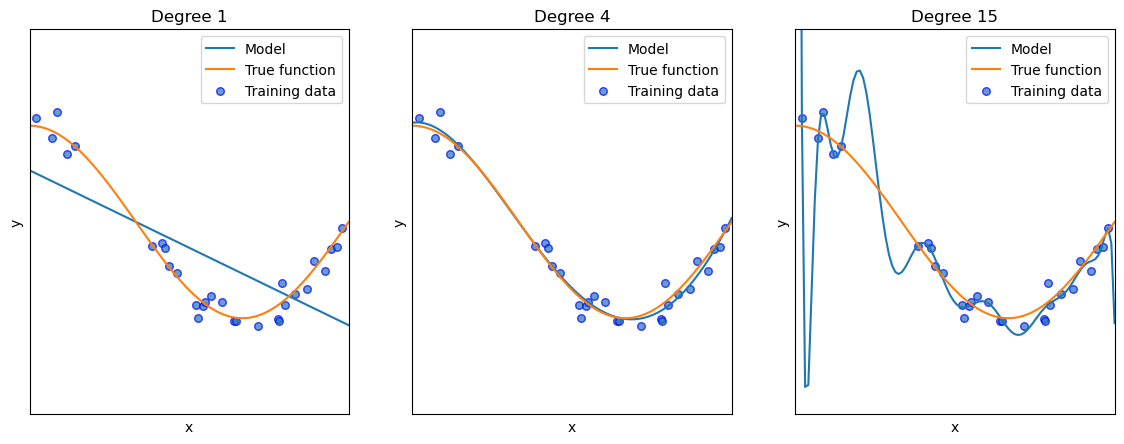

In [2]:
# code based on https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)

n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    Xs = np.linspace(0, 1, 100)
    plt.plot(Xs, pipeline.predict(Xs[:, np.newaxis]), label="Model")
    plt.plot(Xs, true_fun(Xs), label="True function")
    plt.scatter(X, y, edgecolor='b', s=30, alpha=0.7,label="Training data")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}".format(degrees[i]))


To make the under/overfitting tradeoff concrete, let's plot the training and validation error across the full range of polynomial degrees. We evaluate each model on a large held-out validation set drawn from the same distribution as the training data.

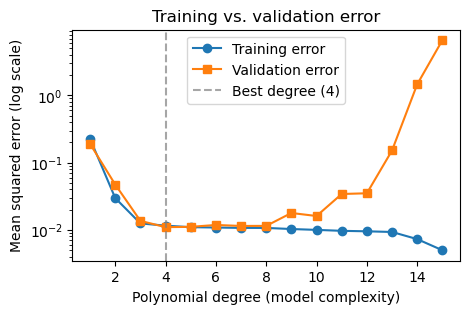

In [5]:
# Training vs. validation error as a function of polynomial degree.
from sklearn.metrics import mean_squared_error

# A large validation set from the same data-generating process
X_val = np.sort(np.random.rand(1000))
y_val = true_fun(X_val) + np.random.randn(1000) * 0.1

all_degrees = range(1, 16)
train_err, val_err = [], []
for d in all_degrees:
    pipeline = Pipeline([("polynomial_features",
                          PolynomialFeatures(degree=d, include_bias=False)),
                         ("linear_regression", LinearRegression())])
    pipeline.fit(X[:, np.newaxis], y)
    train_err.append(mean_squared_error(y, pipeline.predict(X[:, np.newaxis])))
    val_err.append(mean_squared_error(y_val, pipeline.predict(X_val[:, np.newaxis])))

best_degree = list(all_degrees)[int(np.argmin(val_err))]

plt.figure(figsize=(5, 3))
plt.plot(list(all_degrees), train_err, 'o-', label="Training error")
plt.plot(list(all_degrees), val_err, 's-', label="Validation error")
plt.axvline(best_degree, color='gray', linestyle='--', alpha=0.7,
            label=f"Best degree ({best_degree})")
plt.yscale("log")
#use a log scale on the $y$-axis because the validation error spans several orders of magnitude.
plt.xlabel("Polynomial degree (model complexity)")
plt.ylabel("Mean squared error (log scale)")
plt.title("Training vs. validation error")
plt.legend(loc="best");

While mapping our data to a higher dimensional feature space is very useful for being able to model data that exhibit non-linear relationships, that increased flexibility can lead to dangerous consequences and can result in **overfitting**.

We observe that with increased feature-space dimensionality the resulting regression function has increased flexibility.  There is a sweet-spot that provides optimal performance, and once we go past that, our regression function, although it fits the data quite well, begins to behave erratically outside the training data.  It has become too flexible and exhibits **overfitting**.  A model that is overfitting is not likely to generalize well to unseen data.  It is too focused on fitting the data, which is not a good idea:  real-world data contains noise, and what we are interested in is learning the underlying patterns, rather than specifics of a particular training set.

### The characteristics of overfitting

A model that is overfitting has the following characteristics:

- It matches the training set too closely.
- It does well on the training data, but doesn't *generalize* to new data.  In other words, it performs poorly on independent test data.
- It learns the noise in the data, rather than the signal.


### Generalization as a function of model complexity

A higher-order polynomial function is more complex
than a lower-order polynomial function,
since the higher-order polynomial has more parameters
and the model can generate functions that exhibit greater variability.
For a given training dataset,
higher-order polynomial functions should always
achieve lower (at worst, equal) training error
relative to lower-degree polynomials.
In fact, a polynomial function with degree
equal to the number of data examples
can fit the training set perfectly (assuming the $x$'s are unique).
We describe the relationship between polynomial degree (model complexity)
and both underfitting and overfitting in the following figure:

In [ ]:
def capacity_vs_error_figure():
    """Training and generalization error as model complexity grows."""
    from matplotlib.patches import FancyArrowPatch

    blue, red, grey = '#2c6d9e', '#c1440e', '0.45'
    c = np.linspace(0.02, 1.0, 500)

    train = 0.16 + 0.80 * np.exp(-4.4 * c)      # falls monotonically, forever
    gap = 0.06 * (np.exp(2.4 * c) - 1.0)        # the price of extra capacity
    gen = train + gap
    k = int(np.argmin(gen))
    best = c[k]

    fig, ax = plt.subplots(figsize=(6.8, 4.0))
    ax.axvspan(c[0], best, color='#eef3f8', zorder=0)
    ax.axvspan(best, c[-1], color='#f6f0f4', zorder=0)
    ax.plot(c, gen, color=red, linewidth=1.9, zorder=3,
            label='generalization error')
    ax.plot(c, train, color=blue, linewidth=1.9, zorder=3,
            label='training error')

    ax.axvline(best, color=grey, linewidth=0.9, linestyle=(0, (4, 3)), zorder=2)
    ax.plot([best], [gen[k]], marker='o', markersize=5, color=red, zorder=4)

    top = 1.06
    ax.text(best / 2, top, 'underfitting', ha='center', va='top', fontsize=10,
            color='0.3', fontweight='bold')
    ax.text((best + 1.0) / 2, top, 'overfitting', ha='center', va='top',
            fontsize=10, color='0.3', fontweight='bold')

    ax.annotate('best model', xy=(best, gen[k]), xytext=(best - 0.17, 0.68),
                fontsize=9, color='0.25', ha='center', va='center',
                arrowprops=dict(arrowstyle='-', color='0.55', linewidth=0.8))

    # the gap, measured at the right-hand edge
    j = -22
    ax.add_patch(FancyArrowPatch((c[j], train[j]), (c[j], gen[j]),
                                 arrowstyle='<|-|>', mutation_scale=7,
                                 linewidth=0.9, color='0.35', shrinkA=0,
                                 shrinkB=0, zorder=4))
    ax.text(c[j] - 0.02, (train[j] + gen[j]) / 2, 'generalization gap',
            ha='right', va='center', fontsize=8, color='0.3', zorder=5,
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor='none', alpha=0.85))

    ax.set_xlabel('model complexity')
    ax.set_ylabel('error')
    ax.set_xlim(c[0], c[-1])
    ax.set_ylim(0, 1.10)
    ax.set_xticks([]); ax.set_yticks([])
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('0.5')
    ax.legend(loc='lower left', bbox_to_anchor=(0.03, 0.04), frameon=False,
              fontsize=9)
    fig.tight_layout()

capacity_vs_error_figure()

### Dataset Size

Dataset size is a big consideration when considering generalization.
For a given model, the fewer samples we have in the training dataset,
the more likely (and more severely)
we are to encounter overfitting.
As we increase the amount of training data,
the generalization error typically decreases.
Moreover, in general, more data almost never hurts.

Absent sufficient data, simpler models
may be more difficult to beat.
For many tasks, deep learning
only outperforms linear models
when many thousands of training examples are available.
In part, the current success of deep learning
owes considerably to the abundance of massive datasets
arising from Internet companies, cheap storage,
connected devices, and the broad digitization of the economy.


### Model Selection

Typically, we select our final model
only after evaluating multiple models
that differ in various ways
(different architectures, training objectives,
selected features, data preprocessing,
learning rates, etc.).
Choosing among many models is
called *model selection*.

In principle, we should not touch our test set
until after we have chosen all our hyperparameters.
Were we to use the test data in the model selection process,
there is a risk that we might overfit the test data.
Then we would be in serious trouble.
If we overfit our training data,
there is always the evaluation on test data to keep us honest.
But if we overfit the test data, how would we ever know?

Thus, we should never rely on the test data for model selection.
And yet we cannot rely solely on the training data
for model selection either because
we cannot estimate the generalization error
on the very data that we use to train the model.


In practical applications, the picture gets muddier.
While ideally we would only touch the test data once,
to assess the very best model or to compare
a small number of models with each other,
real-world test data is seldom discarded after just one use.
We can seldom afford a new test set for each round of experiments.
In fact, recycling benchmark data for decades
can have a significant impact on the
development of algorithms,
e.g., for [image classification](https://paperswithcode.com/sota/image-classification-on-imagenet)
and [optical character recognition](https://paperswithcode.com/sota/image-classification-on-mnist).

The common practice for addressing the problem of *training on the test set*
is to split our data three ways,
incorporating a *validation set*
in addition to the training and test datasets.
The result is a murky business where the boundaries
between validation and test data are worryingly ambiguous.
Unless explicitly stated otherwise, in the experiments in this course
we are really working with what should rightly be called
training data and validation data, with no true test sets.
Therefore, the accuracy reported in each experiment of the course is really
the validation accuracy and not a true test set accuracy.


## Summary

This section explored some of the  underpinnings
of generalization in  machine learning.
Some of these ideas become complicated and counterintuitive when we get to deeper models where models are capable of overfitting data badly, and the relevant notions of complexity can be both counterintuitive
(e.g., larger architectures with more parameters
generalizing better).
We leave you with a few rules of thumb:

1. Use validation sets for model selection;
1. More complex models often require more data;
1. Relevant notions of complexity include both the number of parameters and the range of values that they are allowed to take;
1. Keeping all else equal, more data almost always leads to better generalization;
1. This entire talk of generalization is all predicated on the IID assumption. If we relax this assumption, allowing for distributions to shift between the train and testing periods, then we cannot say anything about generalization absent a further (perhaps milder) assumption.

In the next notebook, we will see how to avoid overfitting using **regularization**.  This will allow us to benefit from the flexibility afforded by polynomial regression, and have a model that is less subject to overfitting.

## Exercises

1. Can you give an example of a situtation where a classifier produces zero training error?
1. Your manager gives you a difficult dataset on which your current algorithm does not perform so well. How would you justify to them that you need more data? Hint: you cannot increase the data but you can decrease it.